# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..

In [2]:
import os
import pandas as pd
from impl.config import CONFIG
from impl.utils.visualization import visualize_archived_solutions_by_gen, visualize_archive_solution_over_generations

def list_files_between(directory, start_file, end_file=None):
    files = sorted(os.listdir(directory))
    start_index = files.index(start_file) if start_file in files else None
    if end_file is None:
        end_index = len(files) - 1
    else:
        end_index = files.index(end_file) if end_file in files else None

    if start_index is None or end_index is None:
        raise ValueError("Start file or end file not found in the directory")

    if start_index > end_index:
        start_index, end_index = end_index, start_index
    
    return [os.path.join(directory, file) for file in files[start_index:end_index + 1]]

def read_table_string(table_string, delimeter='|', start_line_with_del=True, empty_lines_after_header=1):
    header = table_string.strip().split('\n')[0].split(delimeter)
    if start_line_with_del: header = header[1:-1]
    header = [col.strip() for col in header]
    rows = [row.split(delimeter)[1:-1] if start_line_with_del else row.split(delimeter)\
                for row in table_string.strip().split('\n')[empty_lines_after_header + 1:]]
    rows = [[element.strip() for element in row] for row in rows]
    df = pd.DataFrame(rows, columns=header)
    return df

/home/hossein/PycharmProjects/automatic-potato/.venv/lib/python3.7/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [3]:
decreasing_cp_table = """
| Solution/Statistics | Start_checkpoint | End_checkpoint |
| :------------------ | :--------------- | :------------- |
| ccea-1727209526466  | 1727201519649    | 1727209525799  |
| ccea-1727240994672  | 1727235598273    | 1727240994238  |
| ccea-1727266901005  | 1727261716665    | 1727266900474  |
| ccea-1727295192682  | 1727288292889    | 1727295192277  |
| ccea-1727323277274  | 1727316247139    | 1727323276634  |
| ccea-1727350900214  | 1727343419222    | 1727350899632  |
| ccea-1727380354661  | 1727373922607    | 1727380353945  |
| ccea-1727411465615  | 1727403610820    | 1727411465040  |
| ccea-1727439594179  | 1727432664046    | 1727439593383  |
| ccea-1727469833556  | 1727462943800    | 1727469832790  |
| ga-1727222567297    | 1727209911905    | 1727222566366  |
| ga-1727250570553    | 1727241404211    | 1727250570021  |
| ga-1727277786075    | 1727267613418    | 1727277785562  |
| ga-1727305247085    | 1727295908578    | 1727305246414  |
| ga-1727332417742    | 1727323806097    | 1727332417270  |
| ga-1727360236396    | 1727351350346    | 1727360235858  |
| ga-1727391457944    | 1727380896561    | 1727391457305  |
| ga-1727421077088    | 1727412055217    | 1727421076474  |
| ga-1727450998141    | 1727440319781    | 1727450997411  |
| ga-1727480862318    | 1727470376451    | 1727480861750  |
| rs-1727232907851    | 1727223364731    | 1727232907448  |
| rs-1727259420090    | 1727251274947    | 1727259419608  |
| rs-1727286578674    | 1727278306501    | 1727286578130  |
| rs-1727314239612    | 1727306232310    | 1727314239208  |
| rs-1727341179646    | 1727333077420    | 1727341179299  |
| rs-1727369189391    | 1727360732518    | 1727369188866  |
| rs-1727401251184    | 1727392085249    | 1727401250811  |
| rs-1727430452614    | 1727421643803    | 1727430452209  |
| rs-1727460765043    | 1727451559666    | 1727460764631  |
| rs-1727490053161    | 1727481385453    | 1727490052651  |
"""

twenty_gen_runs = """
Solution/Statistics Start_checkpoint End_checkpoint
ccea-1724124717202 1731107030598 1731142228049
ga-1731154462873 1731142808471 1731154462238
rs-1731169712180 1731154974341 1731169711499
ccea-1731222845110 1731171837862 1731222842678
ga-1731238781590 1731223378020 1731238780835
rs-1731251319707 1731239534424 1731251319246
ccea-1731380885525 1731344835756 1731380883744
ga-1731388013348 1731381955412 1731388013086
rs-1731402224615 1731388802987 1731402223925
ccea-1731562895033 1731525859909 1731562893045
ga-1731569160119 1731563427425 1731569159684
rs-1731583428875 1731570186157 1731583428343
ccea-1731657789244 1731608244237 1731657786730
ga-1731673664147 1731658311120 1731673663412
rs-1731687610454 1731674189305 1731687609773
"""

dec_cps = read_table_string(decreasing_cp_table)
dec_cps['alg'] = dec_cps['Solution/Statistics'].apply(lambda x: x.split('-')[0])

tw_cps = read_table_string(twenty_gen_runs, delimeter=' ', start_line_with_del=False, empty_lines_after_header=0)
tw_cps['alg'] = tw_cps['Solution/Statistics'].apply(lambda x: x.split('-')[0])

all_cps = pd.concat([dec_cps, tw_cps], ignore_index=True)

CP_BASE = 'out/server_checkpoints'
CP_BASE2 = 'out/server_nandai_checkpoints/'
# CP_BASE = CONFIG["workspace"]["checkpoint"]

In [4]:
def read_all_checkpoints(cps):
    checkpoints = {}
    for i, row in cps.iterrows():
        alg = row['alg']
        if alg not in checkpoints:
            checkpoints[alg] = []
        run = list_files_between(CP_BASE2, f"{row['Start_checkpoint']}.pickle", f"{row['End_checkpoint']}.pickle")
        checkpoints[alg].append(run)
    return checkpoints
def read_start_end(cps):
    checkpoints = {}
    for i, row in cps.iterrows():
        alg = row['alg']
        if alg not in checkpoints:
            checkpoints[alg] = []
        checkpoints[alg].append((row["Start_checkpoint"], row["End_checkpoint"]))
    return checkpoints

dec_checkpoints = read_all_checkpoints(dec_cps)
dec_checkpoints_se = read_start_end(dec_cps)

tw_checkpoints = read_all_checkpoints(tw_cps)
tw_checkpoints_se = read_start_end(tw_cps)

all_checkpoints = read_all_checkpoints(all_cps)
all_checkpoints_se = read_start_end(all_cps)

# APD Across Thresholds

## Dec CPS

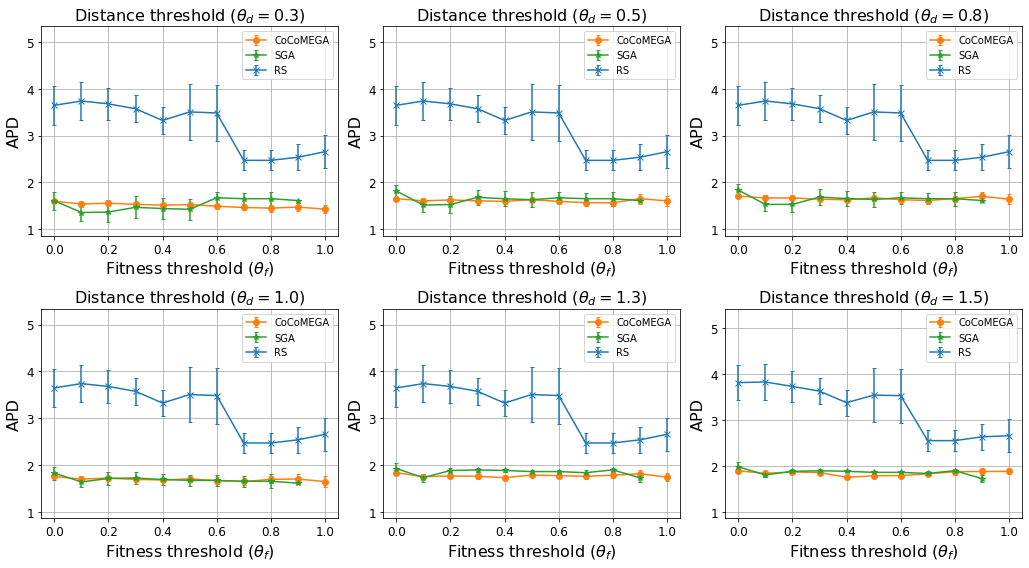

In [11]:
# distance_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
fitness_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# fitness_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5]

df = visualize_archived_solutions_by_gen(dec_checkpoints, generation_num=7, metric_name='avg_pw', fitness_thresholds=fitness_thresholds,
                                          distance_thresholds=distance_thresholds, box=False, show=True, legend_loc='upper right',
                                         padding={'top': 1.2, 'bottom': 0.3})

In [27]:
df['rs'].query('fitness_threshold == 0.9').query('distinct_mr_num > 0')

,fitness_threshold,distance_threshold,violated_mr_num,distinct_mr_num,avg_pw
54,0.9,0.3,5,1,1.899381
55,0.9,0.5,5,1,1.899381
56,0.9,0.8,5,1,1.899381
57,0.9,1.0,5,1,1.899381
58,0.9,1.3,5,1,1.899381
59,0.9,1.5,5,1,1.899381
120,0.9,0.3,5,1,3.149346
121,0.9,0.5,5,1,3.149346
122,0.9,0.8,5,1,3.149346
123,0.9,1.0,5,1,3.149346


## TW CPS

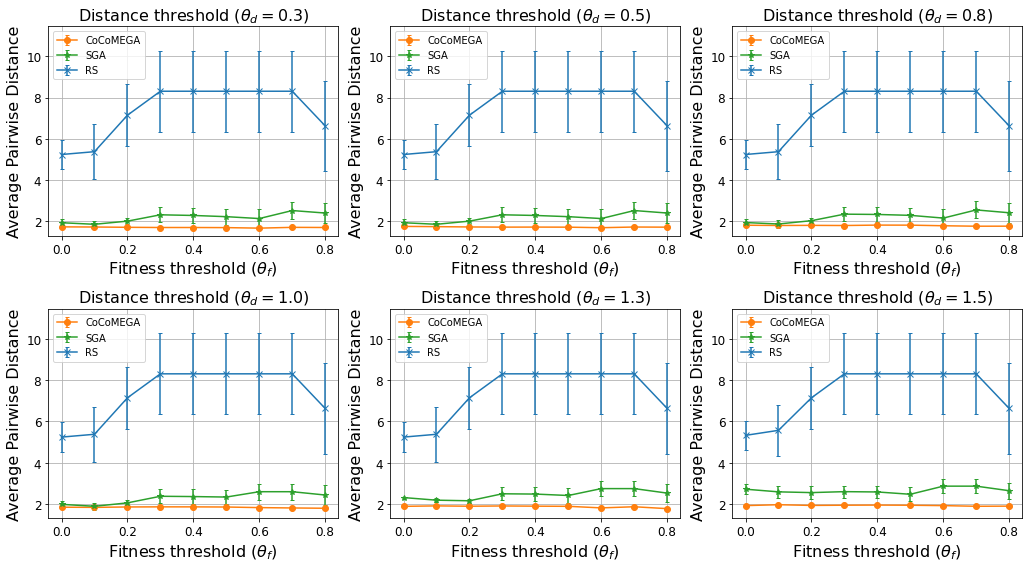

In [11]:
# distance_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
fitness_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5]

df = visualize_archived_solutions_by_gen(tw_checkpoints, generation_num=7, metric_name='avg_pw', fitness_thresholds=fitness_thresholds,
                                          distance_thresholds=distance_thresholds, box=False, show=True, legend_loc='upper left',
                                        padding={'top': 1.2, 'bottom': 0.3})

## All CPS

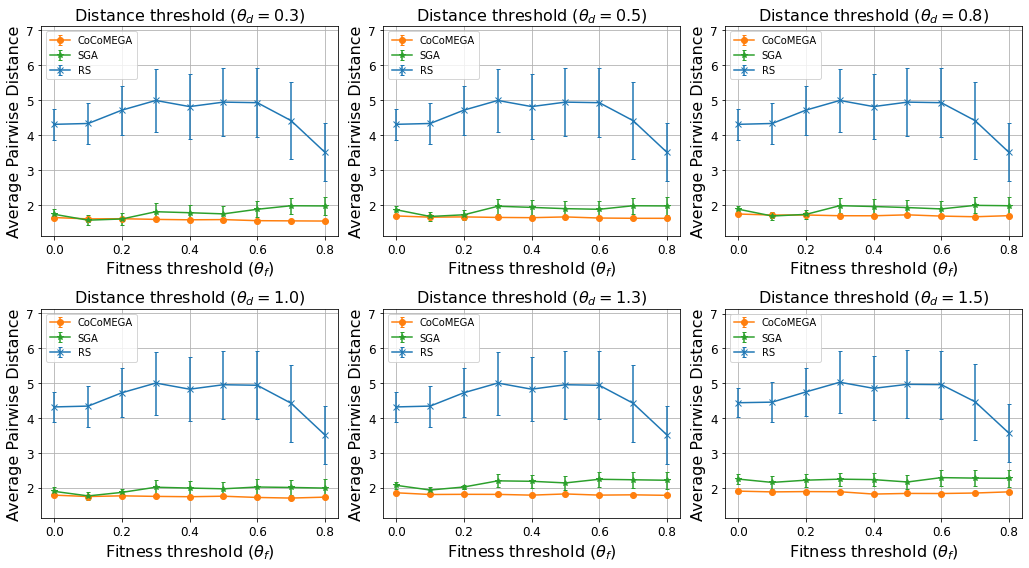

In [19]:
# distance_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
fitness_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5]

df = visualize_archived_solutions_by_gen(all_checkpoints, generation_num=7, metric_name='avg_pw', fitness_thresholds=fitness_thresholds,
                                          distance_thresholds=distance_thresholds, box=False, show=True, legend_loc='upper left',
                                        padding={'top': 1.2, 'bottom': 0.3})

# Archive Solutions Over Generations

## Dec CPS

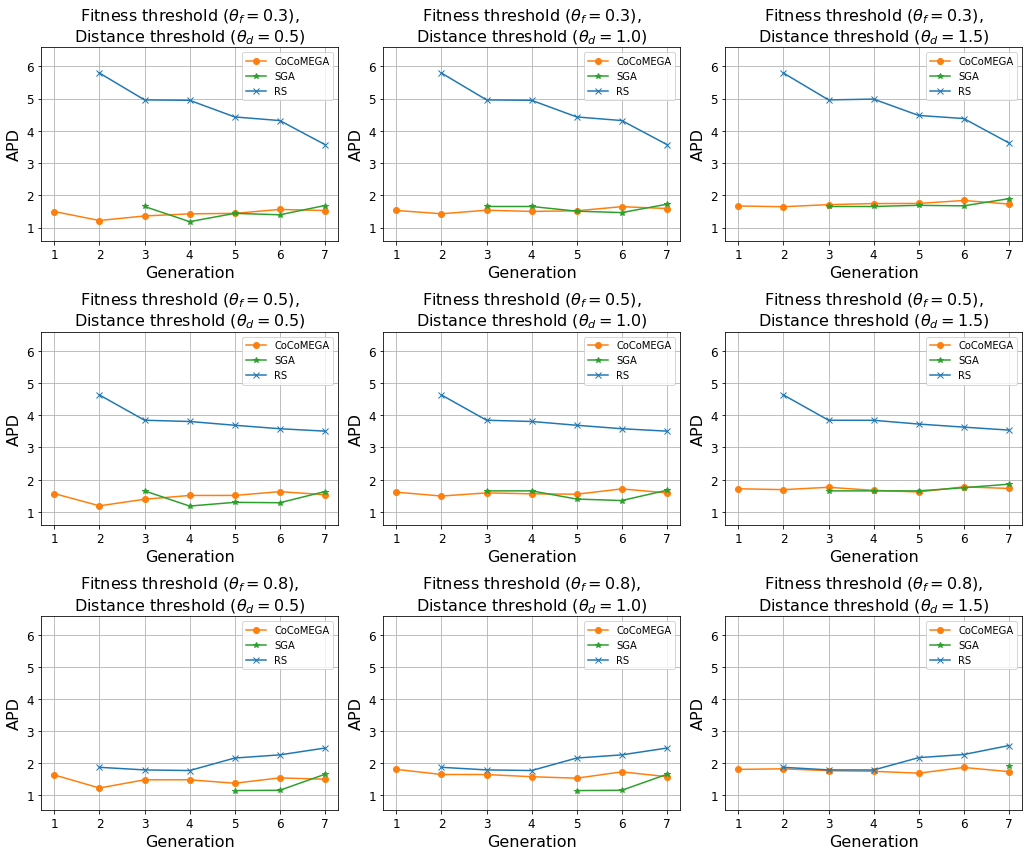

In [30]:
distance_thresholds = [0.5, 1.0, 1.5]
fitness_thresholds = [0.3, 0.5, 0.8]
df = visualize_archive_solution_over_generations(directory=CP_BASE2, files=dec_checkpoints_se, metric_name='avg_pw',
                                                 fitness_thresholds=fitness_thresholds, distance_thresholds=distance_thresholds,
                                                 max_gen=7, show=True, legend_loc='upper right',
                                                padding={'top': 0.8, 'bottom': 0.6})

## TW CPS

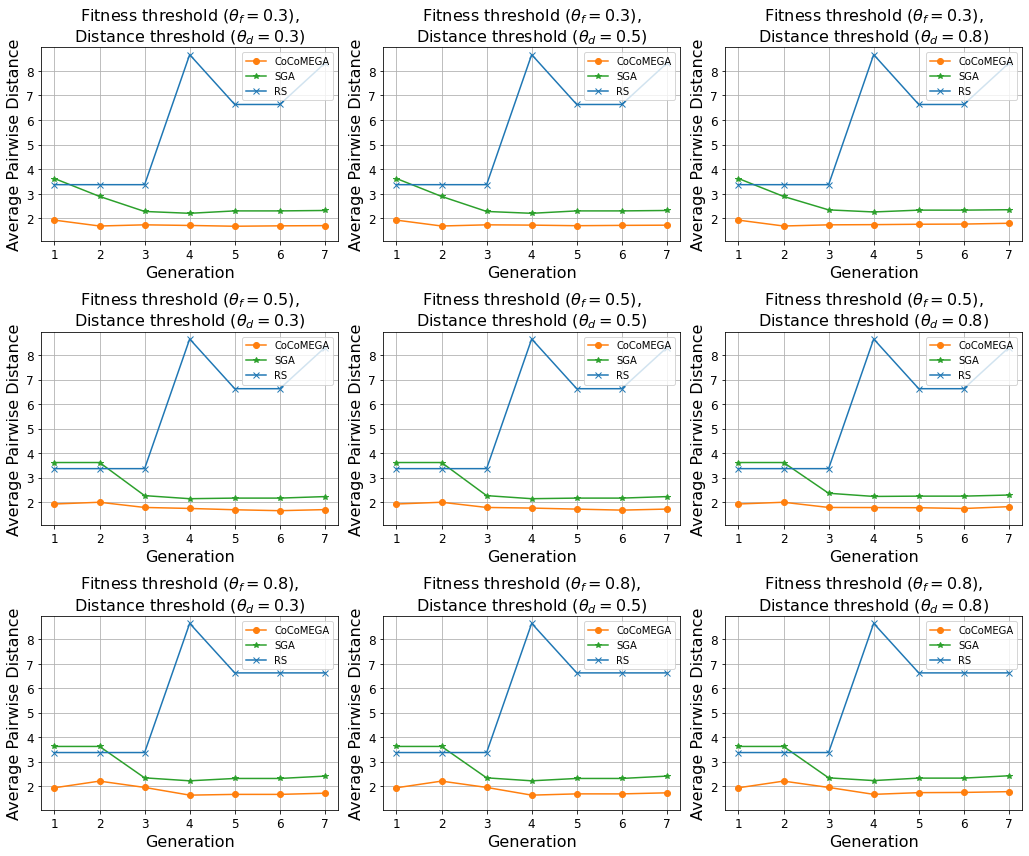

In [14]:
df = visualize_archive_solution_over_generations(directory=CP_BASE2, files=tw_checkpoints_se, metric_name='avg_pw',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=7, show=True, legend_loc='upper right',
                                                padding={'top': 0.3, 'bottom': 0.6})

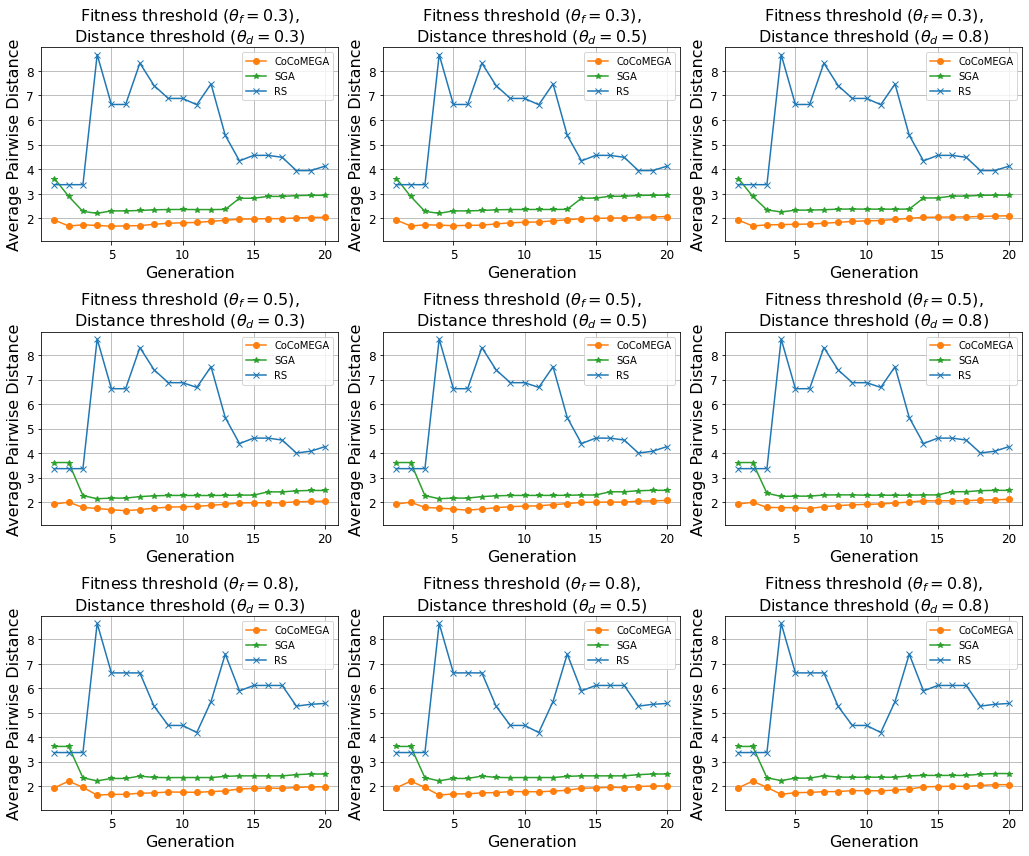

In [21]:
df = visualize_archive_solution_over_generations(directory=CP_BASE2, files=tw_checkpoints_se, metric_name='avg_pw',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=20, show=True, legend_loc='upper right',
                                                padding={'top': 0.3, 'bottom': 0.6})

## ALL CPS

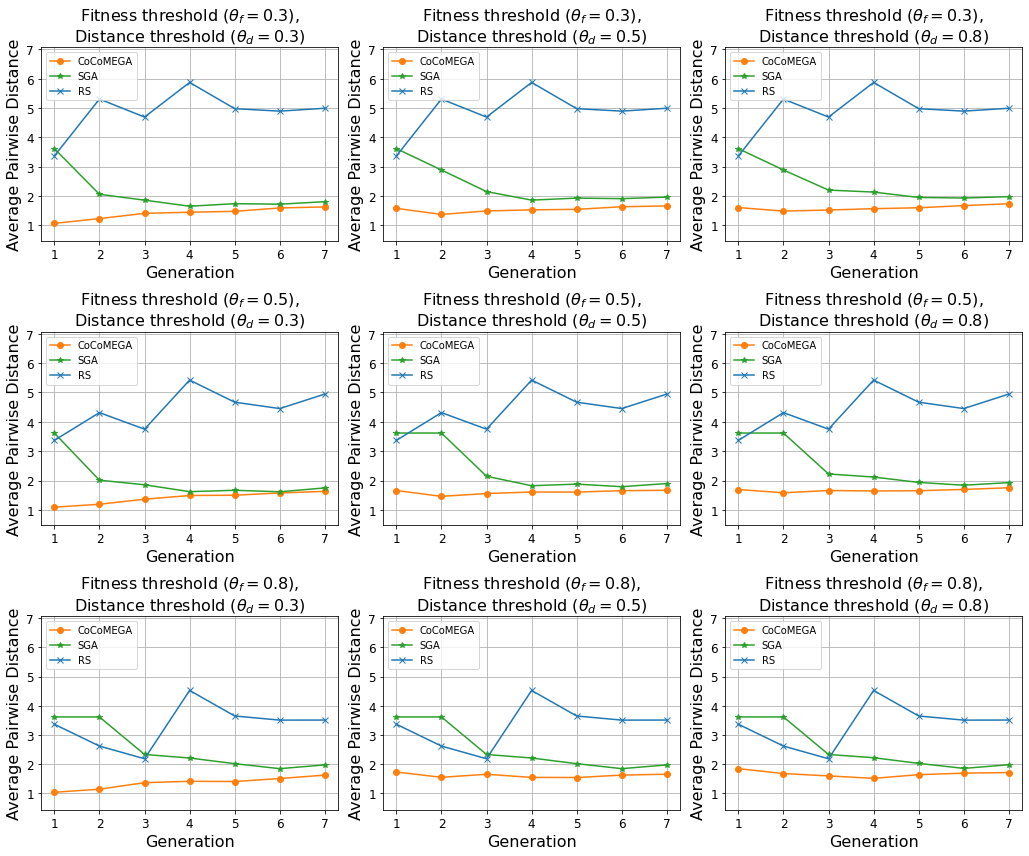

In [20]:
df = visualize_archive_solution_over_generations(directory=CP_BASE2, files=all_checkpoints_se, metric_name='avg_pw',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=7, show=True, legend_loc='upper left',
                                                padding={'top': 1.2, 'bottom': 0.6})

# Other Plots

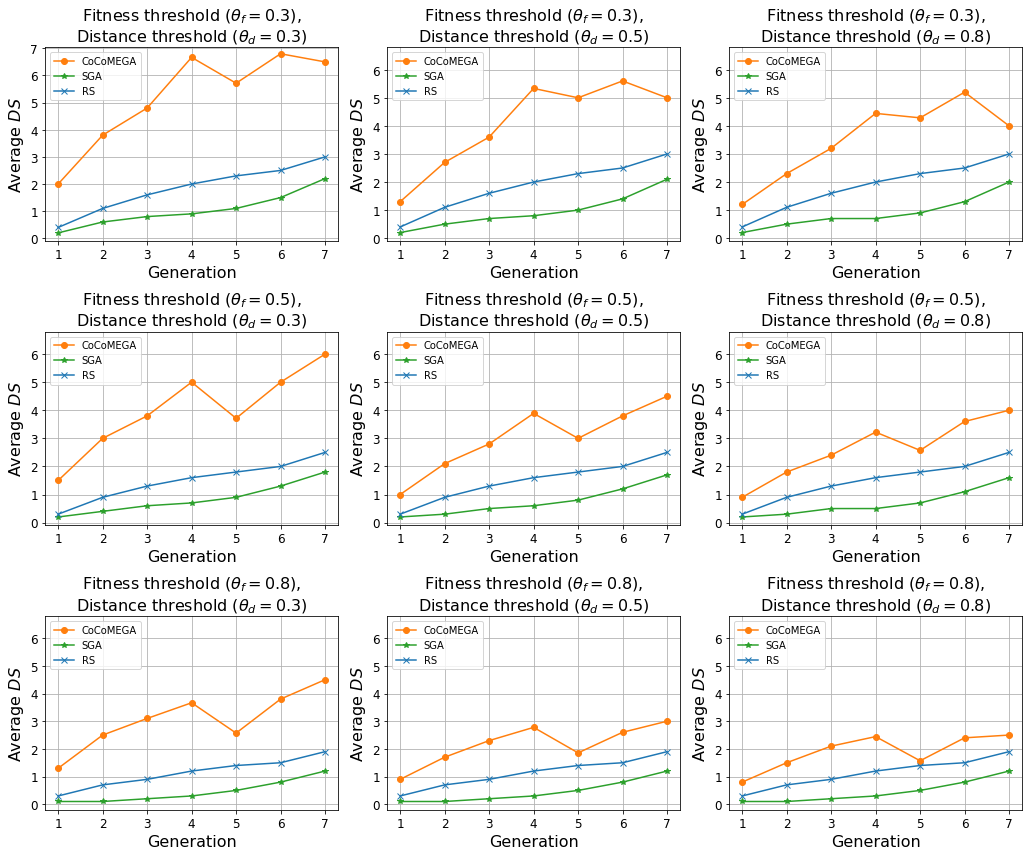

In [9]:
df = visualize_archive_solution_over_generations(directory=CP_BASE, files=checkpoints, metric_name='distinct_solution_num',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=7, show=True, legend_loc='upper left',
                                                padding={'top': 0, 'bottom': 0.3})

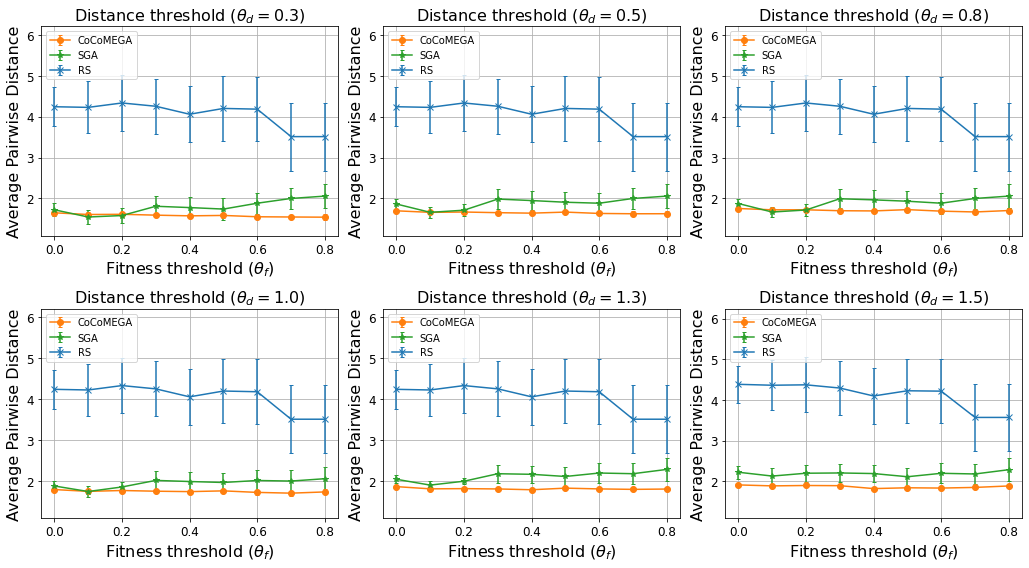

In [31]:
# distance_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
fitness_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5]

df = visualize_archived_solutions_by_gen(all_checkpoints, generation_num=7, metric_name='avg_pw', fitness_thresholds=fitness_thresholds,
                                          distance_thresholds=distance_thresholds, box=False, show=True, legend_loc='upper left',
                                         padding={'top': 1.2, 'bottom': 0.3})

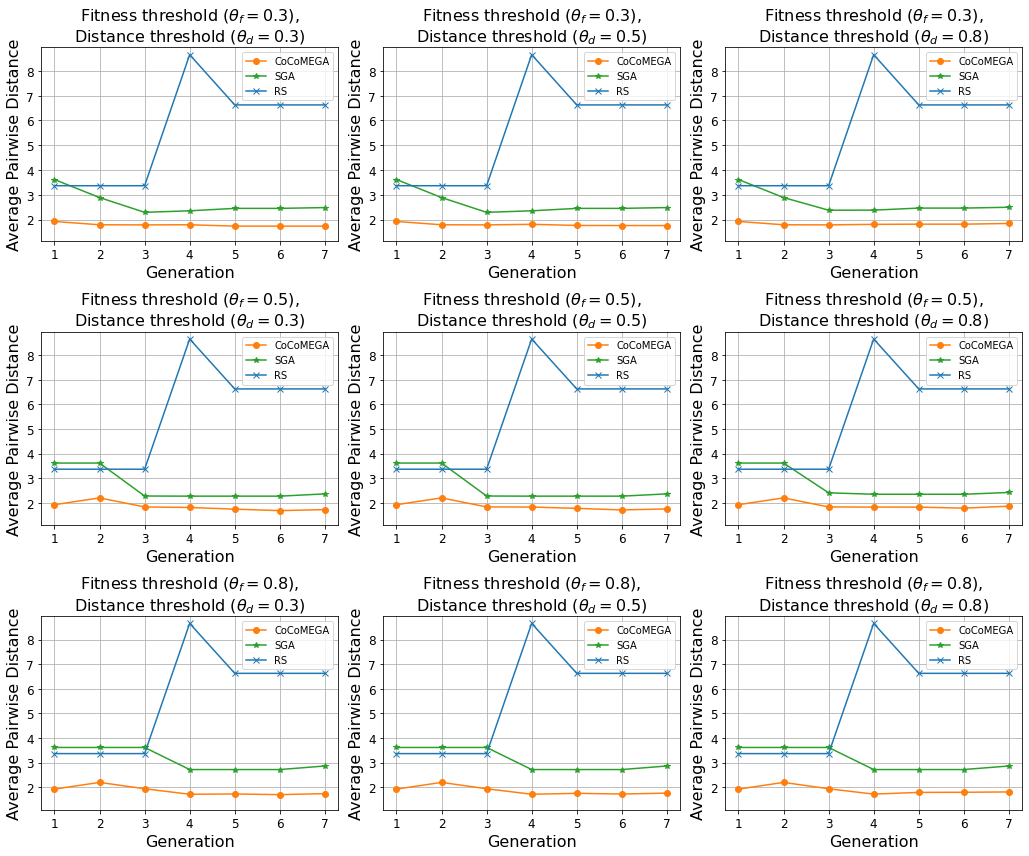

In [53]:
df = visualize_archive_solution_over_generations(directory=CP_BASE2, files=tw_checkpoints_se, metric_name='avg_pw',
                                                 fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.3, 0.5, 0.8],
                                                 max_gen=7, show=True, legend_loc='upper right',
                                                padding={'top': 0.3, 'bottom': 0.6})